## Import libraries and define necessary things

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader
import re
import string
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from torchinfo import summary

In [2]:
torch.manual_seed(2026)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

LEARNING_RATE = 0.002
BATCH_SIZE = 16
EPOCHS = 24

## Prepare the data

### Get the data

In [3]:
!wget https://data.mendeley.com/public-api/zip/39w5khrg87/download/4 -O data.zip

--2026-03-20 15:33:02--  https://data.mendeley.com/public-api/zip/39w5khrg87/download/4
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/39w5khrg87-4.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEHAaCWV1LXdlc3QtMSJHMEUCIQC1qAwuuBEBDTD2OuXnuYQdL15xpmr0XXCk7rwEvQr0DAIgJERpQdqbva01s7zQblFxD92GmQk45di6DtO4n70jzokqjAUIORAEGgwzNjcxNDczODM4MjUiDK%2FLNJ9dBlTs30uR9CrpBLDKqwqzbQG1fW%2FPlv2XMmSYbdeqnecbtLeLpBF7cdbK%2BQZa6tFJHWlbZmBijr5mwdgYMeK4R8Q9KiWVEqcSNJiUUGNg0vdkVO0J3Rgjw67esbA3V%2FFdxvI94Mpmxpl7B9imCoLyIkPxVyF3Zo3gZKeIavvqB6d1O5Q9cTPCwA9QhHM4OoeiJSgSECkgKs8CN%2BMlB1F8bDIXp9pN7%2BNQ4GZ%2F5cNlrLK3siVP4khxsrFdRWKyevE8DdCcig4onYteqOGU5s4MBAf1QTfZ5EAHTidUri2tBr4lBWWCUClSVssruIC1MxCyo685r5dHY9OPzenyGsHBd%2Bsx0w%2FirzFpZlxoesvSlhjhBQy34p2pemxCtZwPhwR3%2Bo4%2F

In [4]:
!unzip -q data.zip

In [5]:
df = pd.read_excel("BanglaTense A Large-Scale Dataset of Bangla Sentences Categorized by Tense Past, Present, and Future/Cleaned-BanglaTense-WithEnglishTranslation.xlsx")

In [6]:
df.sample(10)

,Bangla Sentence,English Translation,Tense
5521,আর্থিক সমৃদ্ধি কমেছিল,Financial prosperity declined,Past
9591,ট্যাবলেট খুলা হয়েছিল আগে,The tablet was opened earlier,Past
17699,আমাদের সম্পর্ক ভবিষ্যতে শেষ হয়ে যাবে,Our relationship will end in the future,Future
4317,জীবনকে সহজে করিয়াছে,Made life easy,Present
2079,যুদ্ধের মাধ্যমে আমরা সবকিছু হারিয়ে যাচ্ছি যেটা...,Through war we are losing everything that sadd...,Present
1608,আমরা আগামীকাল উন্নত মানের শিক্ষা উন্নয়ন নিয়ে...,Tomorrow we will conduct a scientific study on...,Future
4014,এই ছবিটি দেখে এখনও কাঁধি ভুলতাম না সালমান শাহকে,"After watching this film, I still couldn't for...",Past
4764,গুগল ব্রাউজ করিতেছিলাম,I was browsing google,Past
3036,দরিদ্ররা যে বেঁচে আছে এটাই তাদের সক্ষমতার স্পষ...,The survival of the poor is a clear proof of t...,Present
12913,গান বাজতে শুরু হবে,The music will start playing,Future


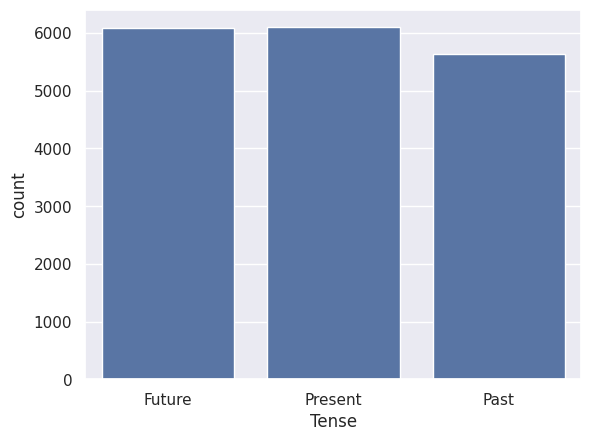

Tense
Present    0.342387
Future     0.341714
Past       0.315899
Name: proportion, dtype: float64

In [7]:
sns.set_theme("notebook")
sns.countplot(df, x="Tense")

plt.show()

df["Tense"].value_counts(normalize=True)

### Split into train, validation and test

In [8]:
classes = {"Past": 0, "Present": 1, "Future": 2}

X = df["Bangla Sentence"]
y = df["Tense"].map(classes)

# split train, test, validation
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=2026)

### Create dataset for training

In [9]:
def clean_text(x):
    x = x.strip().lower()
    x = re.sub(r'^\W+|\d+', '', x)
    # remove punctuation
    x = x.translate(str.maketrans('', '', string.punctuation))
    return x


vocab = []
def build_vocab(x):
    x = clean_text(x)
    # split on any whitespace and filter out empty tokens
    words = [w for w in re.split(r'\s+', x) if w]
    vocab.extend(words)

X.apply(build_vocab)

vocab = set(vocab)
vocab2idx = {char: i for i, char in enumerate(sorted(vocab), 2)}
vocab2idx[""] = 0
vocab2idx["*unk*"] = 1
idx2vocab = {v: k for k, v in vocab2idx.items()}

vocab_size = len(vocab2idx)
vocab_size

12312

In [10]:
def encode(x):
  x = clean_text(x)
  words = [w for w in re.split(r"\s+", x) if w]
  return [vocab2idx.get(word, 1) for word in words]

# Encode training and testing data
x_train_enc = x_train.apply(encode)
x_test_enc = x_test.apply(encode)
x_val_enc = x_val.apply(encode)

# Pad sequences to a fixed length
def pad_sequence(seq, max_len=100):
    if len(seq) < max_len:
        return seq + [0] * (max_len - len(seq))
    else:
        return seq[:max_len]

x_train_pd = torch.tensor(list(x_train_enc.apply(pad_sequence)))
x_test_pd = torch.tensor(list(x_test_enc.apply(pad_sequence)))
x_val_pd = torch.tensor(list(x_val_enc.apply(pad_sequence)))


y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)
y_val = torch.tensor(y_val.values)

print(f"Shape of processed training data: {x_train_pd.shape}")
print(f"Shape of processed test data: {x_test_pd.shape}")
print(f"Shape of processed Validation data: {x_val_pd.shape}")

Shape of processed training data: torch.Size([11404, 100])
Shape of processed test data: torch.Size([3564, 100])
Shape of processed Validation data: torch.Size([2851, 100])


In [11]:
train_data = torch.utils.data.TensorDataset(x_train_pd, y_train)
val_data = torch.utils.data.TensorDataset(x_val_pd, y_val)
test_data = torch.utils.data.TensorDataset(x_test_pd, y_test)

## Build model

In [12]:
class TenseDetector(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 256, padding_idx=0)
        self.transformer = nn.TransformerDecoderLayer(d_model=256, nhead=4, batch_first=True)
        self.h = nn.Sequential(
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.fc = nn.Linear(64, num_classes)


    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x, x) # Pass x as both target and memory
        # Use the last hidden state from the sequence (dim 1)
        x = x[:, -1, :]
        x = self.h(x)
        x = self.fc(x)
        return x

In [13]:
model = TenseDetector(vocab_size, len(classes)).to(device, non_blocking=True)

summary(model, input_size=(1, 100), device=device, dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
TenseDetector                            [1, 3]                    --
├─Embedding: 1-1                         [1, 100, 256]             3,151,872
├─TransformerDecoderLayer: 1-2           [1, 100, 256]             --
│    └─MultiheadAttention: 2-1           [1, 100, 256]             263,168
│    └─Dropout: 2-2                      [1, 100, 256]             --
│    └─LayerNorm: 2-3                    [1, 100, 256]             512
│    └─MultiheadAttention: 2-4           [1, 100, 256]             263,168
│    └─Dropout: 2-5                      [1, 100, 256]             --
│    └─LayerNorm: 2-6                    [1, 100, 256]             512
│    └─Linear: 2-7                       [1, 100, 2048]            526,336
│    └─Dropout: 2-8                      [1, 100, 2048]            --
│    └─Linear: 2-9                       [1, 100, 256]             524,544
│    └─Dropout: 2-10                     [1, 100, 256]  

## Train the model

In [14]:
@torch.no_grad()
def evaluate(model, data_loader):
  model.eval()

  loss_fn = nn.CrossEntropyLoss()
  total_loss = 0
  total_acc = 0

  for inp, tar in tqdm(data_loader, desc="Validating"):
     inp = inp.to(device, non_blocking=True)
     tar = tar.to(device, non_blocking=True)
     out = model(inp)

     loss = loss_fn(out, tar)
     pred_classes = torch.argmax(torch.softmax(out, dim=1), dim=1)
     accuracy = (pred_classes == tar).float().mean().item()

     total_loss += loss.item()
     total_acc += accuracy

  return total_loss/len(data_loader), total_acc/len(data_loader)

In [15]:
def train_model(model: nn.Module, train_data: torch.utils.data.TensorDataset, val_data: torch.utils.data.TensorDataset, *, batch: int, epochs: int, lr: float=0.05)  -> list:
   """
   Train the model with defined epochs and log the training loss and accuracy
   """
   if torch.cuda.device_count() > 1:
       model = nn.DataParallel(model)

   log = []
   loss_fn = nn.CrossEntropyLoss()
   optimizer = torch.optim.Adam(model.parameters(), lr=lr)
   scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
   train_loader = DataLoader(train_data, batch_size=batch, shuffle=True, pin_memory=True)
   val_loader = DataLoader(val_data, batch_size=batch, pin_memory=True)

   for epoch in range(epochs):
      total_loss = 0
      total_acc = 0
      model.train()

      for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch: {epoch+1}/{epochs}"):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        y_hat = model(x_batch)
        loss = loss_fn(y_hat, y_batch)
        pred = torch.softmax(y_hat, dim=1)
        y_pred = torch.argmax(pred, dim=1)
        accuracy = (y_pred == y_batch).float().mean()

        # heroic steps
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy.item()

      scheduler.step()
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

      # calculation for average loss and accuracy per epoch
      avg_loss = total_loss / len(train_loader)
      avg_acc = total_acc / len(train_loader)

      # validate the model
      loss, acc = evaluate(model, val_loader)

      log.append({
        "epochs": epoch+1,
        "training_loss": avg_loss,
        "training_accuracy": avg_acc,
        "validation_loss": loss,
        "validation_accuracy": acc
      })
   return log

In [16]:
log = train_model(
    model=model,
    train_data=train_data,
    val_data=val_data,
    batch=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

Epoch: 1/24:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch: 2/24:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch: 3/24:   0%|          | 0/713 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch: 23/24:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch: 24/24:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

In [17]:
log_df = pd.DataFrame(log)

log_df

,epochs,training_loss,training_accuracy,validation_loss,validation_accuracy
0,1,0.659748,0.711343,0.481388,0.791434
1,2,0.439502,0.830353,0.405655,0.850209
2,3,0.333829,0.879003,0.365905,0.872556
3,4,0.236469,0.918420,0.300583,0.898045
4,5,0.172325,0.945302,0.325877,0.894553
5,6,0.137393,0.958275,0.295213,0.910615
6,7,0.099023,0.970985,0.272237,0.915154
7,8,0.083077,0.974404,0.297348,0.917249
8,9,0.071847,0.979663,0.350790,0.913757
9,10,0.060195,0.984455,0.317311,0.921089


In [18]:
# best epoch

log_df.loc[log_df["validation_accuracy"].idxmax()]

epochs                 24.000000
training_loss           0.012975
training_accuracy       0.996669
validation_loss         0.418774
validation_accuracy     0.923883
Name: 23, dtype: float64

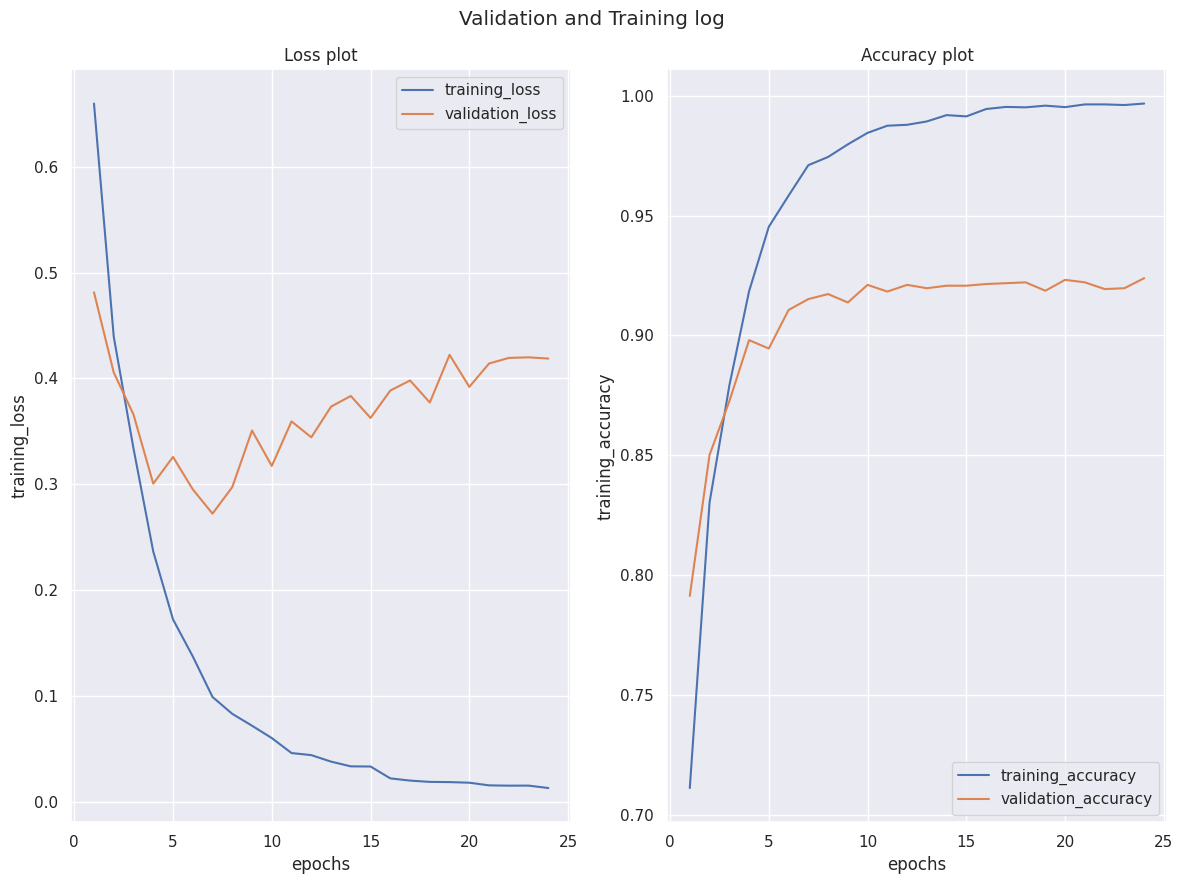

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 9))

sns.lineplot(data=log_df, x="epochs", y="training_loss", ax=ax[0], label="training_loss")
sns.lineplot(data=log_df, x="epochs", y="validation_loss", ax=ax[0], label="validation_loss")
sns.lineplot(data=log_df, x="epochs", y="training_accuracy", ax=ax[1], label="training_accuracy")
sns.lineplot(data=log_df, x="epochs", y="validation_accuracy", ax=ax[1], label="validation_accuracy")

ax[0].set_title("Loss plot")
ax[1].set_title("Accuracy plot")

plt.suptitle("Validation and Training log")
plt.tight_layout()
plt.show()

## Evaluate and Test the model

In [20]:
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, pin_memory=True)
evaluate(model, test_loader)

Validating:   0%|          | 0/223 [00:00<?, ?it/s]

(0.4031586363879523, 0.9258221227491917)

In [21]:
@torch.no_grad()
def predict(model, text):
  idx2label = {v: k for k, v in classes.items()}
  text = clean_text(text)
  words = [w for w in re.split(r"\s+", text) if w] # Corrected tokenization
  enc = [vocab2idx.get(word, 1) for word in words]
  enc_tn = torch.tensor(enc, device=device)

  logits = model(enc_tn.unsqueeze(0))
  prob = torch.softmax(logits, dim=1)
  pred_idx = torch.argmax(prob, dim=1)

  return [idx2label[pred_idx.item()], prob[0, pred_idx.item()].item()]

In [22]:
text = "২০১৭ সালে ট্রান্সফর্মার ১ম তৈরি হয়েছিল"

predict(model, text)

['Past', 0.9879103899002075]

In [23]:
text = "কৃত্রিম বুদ্ধিমত্তা অনেক আবিষ্কারে ভূমিকা পালন করবে"

predict(model, text)

['Future', 0.9993948936462402]

In [24]:
text = "সূর্য দক্ষিণ দিক দিয়ে ওঠে না"

predict(model, text)

['Present', 0.9998676776885986]